# Results

# TODOs
- TODO: Plot the decay of GP uncertainty (Sigma) across SH rounds for synthetic experiments with early stopping (requires Sigma to be logged in sh_iterations logtable first)

In [1]:
from py_experimenter.experimenter import PyExperimenter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Load Data

In [2]:
TABLE_NAMES_NORMALIZED = [
    "new_stopping_successive_halving_no_es",
    "new_stopping_successive_halving_es",
    "new_stopping_hyperband_no_es",
    "new_stopping_hyperband_es",
    "new_stopping_priorband_no_es",
    "new_stopping_priorband_es",
]
TABLE_NAMES_SH_UNNORMALIZED = [
    "new_stopping_successive_halving_no_es",
    "new_stopping_successive_halving_es",
]
TABLE_NAMES_SYNTHETIC = [
    "new_stopping_synthetic_no_es",
    "new_stopping_synthetic_es",
]
update_data = True

def get_data(table_name: str, update_data: bool) -> pd.DataFrame | None:
    cache_path = f"plain_data/{table_name}/table.csv"
    if update_data:
        try:
            experimenter = PyExperimenter(
                experiment_configuration_file_path="conf/experiment_config.yml",
                database_credential_file_path="conf/database_credentials.yml",
                table_name=table_name,
            )
            df = experimenter.get_table()
            os.makedirs(os.path.dirname(cache_path), exist_ok=True)
            df.to_csv(cache_path, index=False)
            return df
        except Exception as e:
            print(f"Could not load '{table_name}' from DB: {e}")
            if os.path.exists(cache_path):
                print(f"  Falling back to cached data for '{table_name}'.")
                return pd.read_csv(cache_path)
            return None
    else:
        if not os.path.exists(cache_path):
            print(f"No cache found for '{table_name}', skipping.")
            return None
        return pd.read_csv(cache_path)

dfs_norm = [get_data(t, update_data) for t in TABLE_NAMES_NORMALIZED]
available_norm = [d for d in dfs_norm if d is not None and not d.empty]
if not available_norm:
    raise RuntimeError("No normalized experiment data found.")
df = pd.concat(available_norm, ignore_index=True)
df = df[df["status"] == "done"]
df_lcbench = df[df["benchmark"] == "lcbench"]
print(f"{len(df_lcbench)} completed normalized lcbench experiments")

dfs_unnorm = [get_data(t, update_data) for t in TABLE_NAMES_SH_UNNORMALIZED]
available_unnorm = [d for d in dfs_unnorm if d is not None and not d.empty]
if available_unnorm:
    df_unnorm = pd.concat(available_unnorm, ignore_index=True)
    df_unnorm = df_unnorm[df_unnorm["status"] == "done"]
    df_lcbench_unnorm = df_unnorm[df_unnorm["benchmark"] == "lcbench"]
    print(f"{len(df_lcbench_unnorm)} completed unnormalized SH lcbench experiments")
else:
    df_lcbench_unnorm = pd.DataFrame()
    print("No unnormalized SH data available.")

dfs_synthetic = [get_data(t, update_data) for t in TABLE_NAMES_SYNTHETIC]
available_synthetic = [d for d in dfs_synthetic if d is not None and not d.empty]
if available_synthetic:
    df_synthetic = pd.concat(available_synthetic, ignore_index=True)
    df_synthetic = df_synthetic[df_synthetic["status"] == "done"]
    print(f"{len(df_synthetic)} completed synthetic experiments")
else:
    df_synthetic = pd.DataFrame()
    print("No synthetic data available.")

df_lcbench.head()

2026-05-04 09:41:08,092  | py-experimenter - INFO     | Found 14 keyfields
2026-05-04 09:41:08,093  | py-experimenter - INFO     | Found 6 resultfields
2026-05-04 09:41:08,095  | py-experimenter - INFO     | Found 2 logtables
2026-05-04 09:41:08,098  | py-experimenter - INFO     | Found logtable test_priorband__sh_iterations
2026-05-04 09:41:08,100  | py-experimenter - INFO     | Found logtable test_priorband__brackets
2026-05-04 09:41:08,102  | py-experimenter - WARNING  | No custom section defined in config
2026-05-04 09:41:08,104  | py-experimenter - WARNING  | No codecarbon section defined in config
2026-05-04 09:41:08,109  | py-experimenter - INFO     | Initialized and connected to database
2026-05-04 09:41:08,143  | py-experimenter - INFO     | Found 14 keyfields
2026-05-04 09:41:08,145  | py-experimenter - INFO     | Found 6 resultfields
2026-05-04 09:41:08,145  | py-experimenter - INFO     | Found 2 logtables
2026-05-04 09:41:08,145  | py-experimenter - INFO     | Found logtabl

Could not load 'new_stopping_successive_halving_es' from DB: Execution failed on sql 'SELECT * FROM new_stopping_successive_halving_es': (1146, "Table 'priorbai_neurips.new_stopping_successive_halving_es' doesn't exist")
  Falling back to cached data for 'new_stopping_successive_halving_es'.
Could not load 'new_stopping_hyperband_es' from DB: Execution failed on sql 'SELECT * FROM new_stopping_hyperband_es': (1146, "Table 'priorbai_neurips.new_stopping_hyperband_es' doesn't exist")
  Falling back to cached data for 'new_stopping_hyperband_es'.
Could not load 'new_stopping_priorband_es' from DB: Execution failed on sql 'SELECT * FROM new_stopping_priorband_es': (1146, "Table 'priorbai_neurips.new_stopping_priorband_es' doesn't exist")
  Falling back to cached data for 'new_stopping_priorband_es'.
10841 completed normalized lcbench experiments


2026-05-04 09:41:08,361  | py-experimenter - INFO     | Initialized and connected to database
2026-05-04 09:41:08,387  | py-experimenter - INFO     | Found 14 keyfields
2026-05-04 09:41:08,388  | py-experimenter - INFO     | Found 6 resultfields
2026-05-04 09:41:08,388  | py-experimenter - INFO     | Found 2 logtables
2026-05-04 09:41:08,388  | py-experimenter - INFO     | Found logtable test_priorband__sh_iterations
2026-05-04 09:41:08,389  | py-experimenter - INFO     | Found logtable test_priorband__brackets
2026-05-04 09:41:08,389  | py-experimenter - WARNING  | No custom section defined in config
2026-05-04 09:41:08,389  | py-experimenter - WARNING  | No codecarbon section defined in config
2026-05-04 09:41:08,394  | py-experimenter - INFO     | Initialized and connected to database
2026-05-04 09:41:08,411  | py-experimenter - INFO     | Found 14 keyfields
2026-05-04 09:41:08,411  | py-experimenter - INFO     | Found 6 resultfields
2026-05-04 09:41:08,412  | py-experimenter - INFO

Could not load 'new_stopping_successive_halving_es' from DB: Execution failed on sql 'SELECT * FROM new_stopping_successive_halving_es': (1146, "Table 'priorbai_neurips.new_stopping_successive_halving_es' doesn't exist")
  Falling back to cached data for 'new_stopping_successive_halving_es'.
10826 completed unnormalized SH lcbench experiments
1767 completed synthetic experiments


,ID,run_id,optimizer,num_arms,benchmark,kernel,use_predicted_y,use_early_stopping,seed,dataset_id,...,name,machine,T_max,consumed_budget,remaining_arms,num_epsilon_optimal_arms,regret,epsilon_optimal,end_date,error
0,1,__AUTO__,successive_halving,256,lcbench,linear,0,0,0,0,...,PyExperimenter,cn0101,52.0,1152.0,1.0,16.0,0.000752,1.0,2026-05-02 19:11:14,None
1,2,__AUTO__,successive_halving,256,lcbench,linear,0,0,1,0,...,PyExperimenter,cn0101,52.0,1152.0,1.0,25.0,0.000600,1.0,2026-05-02 19:11:17,None
2,3,__AUTO__,successive_halving,256,lcbench,linear,0,0,2,0,...,PyExperimenter,cn1304,52.0,1152.0,1.0,20.0,0.000825,1.0,2026-05-02 19:12:37,None
3,4,__AUTO__,successive_halving,256,lcbench,linear,0,0,3,0,...,PyExperimenter,cn0103,52.0,1152.0,1.0,20.0,0.000756,1.0,2026-05-02 19:12:33,None
4,5,__AUTO__,successive_halving,256,lcbench,linear,0,0,4,0,...,PyExperimenter,cn1304,52.0,1152.0,1.0,21.0,0.000334,1.0,2026-05-02 19:12:36,None


## Prepare Data

In [3]:
PRIOR_RENAME = {
    "uniform": "Uniform",
    "performance": "Performance",
    "rank": "Rank",
    "inverse_rank": "Inverse Rank",
    "indicator": "Indicator",
}

BASELINE_LABEL = "Baseline"

_tab10 = sns.color_palette("tab10", n_colors=6)
PRIOR_COLOR_MAP = {
    "Rank": _tab10[0],
    "Performance": _tab10[1],
    "Indicator": _tab10[2],
    "Inverse Rank": _tab10[3],
    "Uniform": _tab10[4],
    BASELINE_LABEL: _tab10[5],
}

PRIOR_MARKER_MAP = {
    "Rank": "o",
    "Performance": "s",
    "Indicator": "D",
    "Inverse Rank": "^",
    "Uniform": "v",
    BASELINE_LABEL: "P",
}

def prepare_data(df: pd.DataFrame, optimizer: str) -> pd.DataFrame | None:
    """Method variants (use_early_stopping=1) + baseline (uniform, no early stopping)."""
    method = df[(df["optimizer"] == optimizer) & (df["use_early_stopping"] == 1)].copy()
    baseline = df[
        (df["optimizer"] == optimizer)
        & (df["prior_kind"] == "uniform")
        & (df["use_early_stopping"] == 0)
    ].copy()
    if method.empty and baseline.empty:
        print(f"No data for optimizer '{optimizer}', skipping.")
        return None
    baseline["prior_kind"] = BASELINE_LABEL
    combined = pd.concat([method, baseline], ignore_index=True)
    combined["prior_kind"] = combined["prior_kind"].map(PRIOR_RENAME).fillna(combined["prior_kind"])
    return combined


## Plot

In [4]:
sns.set_theme(style="whitegrid", context="talk")

LABEL_SIZE = 13
TICK_SIZE = 11

MARKER_SIZE = 9
LEGEND_MARKER_SIZE = 10
MARKER_EDGE_WIDTH = 2
CAP_SIZE = 3
ALPHA_BASELINE = 0.6
ALPHA_NORMAL = 0.9

FIG_SIZE_PARETO = (7,4)
FIG_SIZE_ABLATION = (14, 6)
FIG_SIZE_LEGEND = (10, 0.7)

In [5]:
def pareto_plot(data: pd.DataFrame, xlim=None, ylim=None) -> plt.Figure:
    ranked_priors = (
        data.groupby("prior_kind")["consumed_budget"]
        .mean()
        .sort_values()
        .index.tolist()
    )
    if BASELINE_LABEL in ranked_priors:
        ranked_priors = [p for p in ranked_priors if p != BASELINE_LABEL] + [BASELINE_LABEL]

    fig, ax = plt.subplots(figsize=FIG_SIZE_PARETO)

    for prior in ranked_priors:
        subset = data[data["prior_kind"] == prior]
        m_reg = subset["regret"].mean()
        s_reg = subset["regret"].sem()
        m_bud = subset["consumed_budget"].mean()
        s_bud = subset["consumed_budget"].sem()

        is_baseline = prior == BASELINE_LABEL
        ax.errorbar(
            m_bud, m_reg,
            xerr=s_bud, yerr=s_reg,
            fmt=PRIOR_MARKER_MAP.get(prior, "o"),
            label=prior,
            color=PRIOR_COLOR_MAP.get(prior, "gray"),
            markersize=MARKER_SIZE,
            capsize=CAP_SIZE,
            markeredgewidth=MARKER_EDGE_WIDTH,
            alpha=ALPHA_BASELINE if is_baseline else ALPHA_NORMAL,
            linestyle="--" if is_baseline else "-",
        )

    ax.set_xlabel("Consumed Budget")
    ax.set_ylabel("Regret")
    ax.set_ylim(bottom=0)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.tight_layout()
    return fig

In [6]:
def sigma_ablation_plot(df: pd.DataFrame, optimizer: str) -> plt.Figure | None:
    data = df[(df["optimizer"] == optimizer) & (df["use_early_stopping"] == 1)].copy()
    data["prior_kind"] = data["prior_kind"].map(PRIOR_RENAME).fillna(data["prior_kind"])
    data["sigma0"] = data["sigma0"].astype(str)
    if data.empty:
        print(f"No early-stopping data for optimizer '{optimizer}', skipping sigma ablation.")
        return None

    fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE_ABLATION)

    for ax, metric, ylabel in zip(
        axes,
        ["regret", "consumed_budget"],
        ["Regret", "Consumed Budget"],
    ):
        sns.boxplot(
            data=data,
            x="prior_kind",
            y=metric,
            hue="sigma0",
            ax=ax,
            palette="Set2",
        )
        ax.set_ylabel(ylabel, fontsize=LABEL_SIZE)
        ax.set_xlabel(None)
        ax.tick_params(axis="both", labelsize=TICK_SIZE)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=TICK_SIZE)
        ax.grid(True, linestyle="--", alpha=0.6, axis="y")
        if ax.get_legend():
            ax.get_legend().remove()

    plt.tight_layout()
    return fig

In [7]:
OPTIMIZER_MARKER = {
    "Hyperband": "o",
    "PriorBand": "s",
}

def joined_pareto_plot(
    hb_data: pd.DataFrame,
    pb_data: pd.DataFrame,
    xlim=None,
    ylim=None,
) -> plt.Figure:
    combined = pd.concat(
        [hb_data.assign(optimizer_label="Hyperband"), pb_data.assign(optimizer_label="PriorBand")],
        ignore_index=True,
    )

    all_priors = (
        combined.groupby("prior_kind")["consumed_budget"]
        .mean()
        .sort_values()
        .index.tolist()
    )
    if BASELINE_LABEL in all_priors:
        all_priors = [p for p in all_priors if p != BASELINE_LABEL] + [BASELINE_LABEL]

    fig, ax = plt.subplots(figsize=FIG_SIZE_PARETO)

    for opt_label, marker in OPTIMIZER_MARKER.items():
        subset_opt = combined[combined["optimizer_label"] == opt_label]
        for prior in all_priors:
            subset = subset_opt[subset_opt["prior_kind"] == prior]
            if subset.empty:
                continue
            is_baseline = prior == BASELINE_LABEL
            ax.errorbar(
                subset["consumed_budget"].mean(),
                subset["regret"].mean(),
                xerr=subset["consumed_budget"].sem(),
                yerr=subset["regret"].sem(),
                fmt=marker,
                color=PRIOR_COLOR_MAP.get(prior, "gray"),
                markersize=MARKER_SIZE,
                capsize=CAP_SIZE,
                markeredgewidth=MARKER_EDGE_WIDTH,
                alpha=ALPHA_BASELINE if is_baseline else ALPHA_NORMAL,
                linestyle="None",
                label="_nolegend_",
            )

    ax.set_xlabel("Consumed Budget")
    ax.set_ylabel("Regret")
    ax.set_ylim(bottom=0)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.tight_layout()
    return fig

## Synthetic Ablation

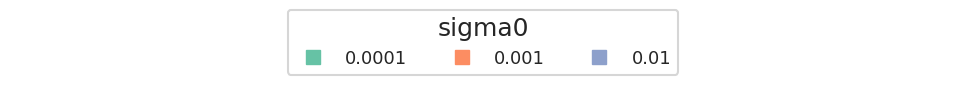

In [8]:
if not df_synthetic.empty:
    _sigma_data = df_synthetic[
        (df_synthetic["optimizer"] == "successive_halving") & (df_synthetic["use_early_stopping"] == 1)
    ]
    _sigma0_vals = sorted(_sigma_data["sigma0"].astype(str).unique())
    _set2 = sns.color_palette("Set2", n_colors=len(_sigma0_vals))
    _sigma_handles = [
        plt.Line2D([0], [0], marker="s", color="w",
                   markerfacecolor=c, markeredgecolor=c,
                   markersize=LEGEND_MARKER_SIZE, label=v)
        for v, c in zip(_sigma0_vals, _set2)
    ]
    _fig_ls, _ax_ls = plt.subplots(figsize=FIG_SIZE_LEGEND)
    _ax_ls.axis("off")
    _ax_ls.legend(
        handles=_sigma_handles,
        labels=[h.get_label() for h in _sigma_handles],
        loc="center",
        ncol=len(_sigma_handles),
        title="sigma0",
        frameon=True,
        fontsize=LABEL_SIZE,
    )
    plt.tight_layout()
    os.makedirs("plots/synthetic/successive_halving", exist_ok=True)
    _fig_ls.savefig("plots/synthetic/successive_halving/legend_sigma.pdf", bbox_inches="tight")
    _fig_ls.savefig("plots/synthetic/successive_halving/legend_sigma.png", bbox_inches="tight", dpi=300)
    plt.show()

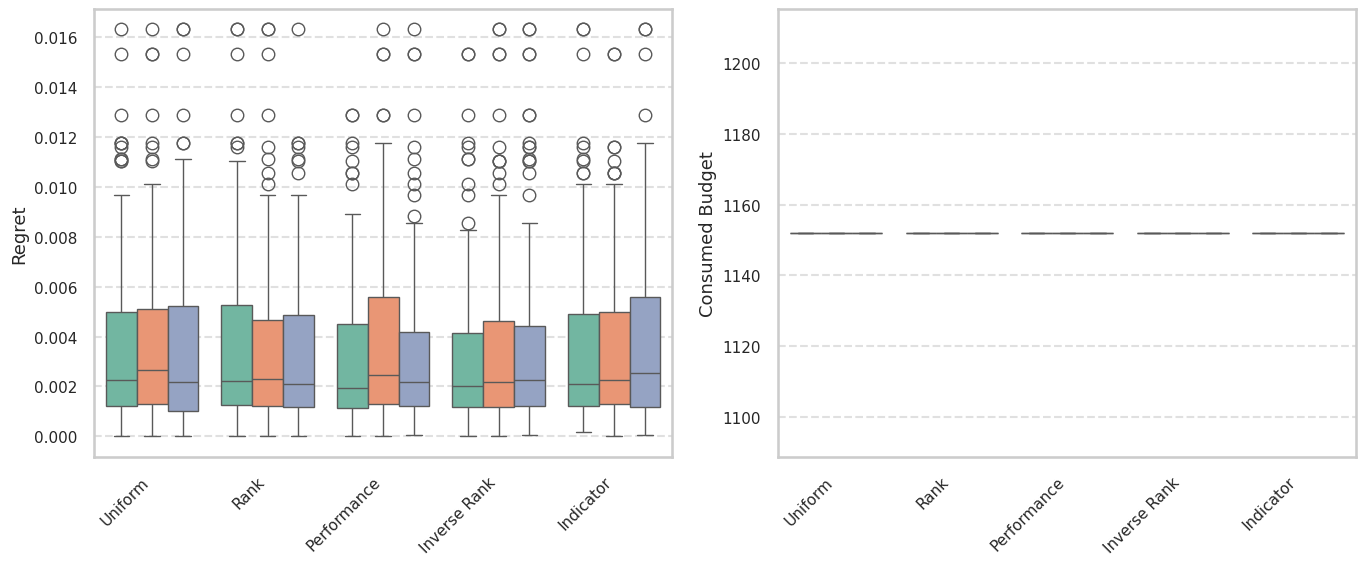

In [9]:
if not df_synthetic.empty:
    fig = sigma_ablation_plot(df_synthetic, "successive_halving")
    if fig is not None:
        os.makedirs("plots/synthetic/successive_halving", exist_ok=True)
        fig.savefig("plots/synthetic/successive_halving/sigma_ablation.pdf", bbox_inches="tight")
        fig.savefig("plots/synthetic/successive_halving/sigma_ablation.png", bbox_inches="tight", dpi=300)
        plt.show()

## Synthetic

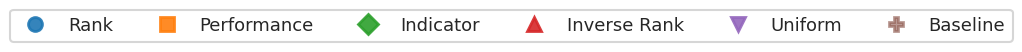

In [10]:
_prior_order = ["Rank", "Performance", "Indicator", "Inverse Rank", "Uniform", BASELINE_LABEL]
_pareto_handles = [
    plt.Line2D(
        [0], [0],
        marker=PRIOR_MARKER_MAP[p],
        color="w",
        markerfacecolor=PRIOR_COLOR_MAP[p],
        markeredgecolor=PRIOR_COLOR_MAP[p],
        markersize=LEGEND_MARKER_SIZE,
        markeredgewidth=MARKER_EDGE_WIDTH,
        alpha=ALPHA_BASELINE if p == BASELINE_LABEL else ALPHA_NORMAL,
        label=p,
    )
    for p in _prior_order
    if p in PRIOR_COLOR_MAP
]
_fig_lp, _ax_lp = plt.subplots(figsize=FIG_SIZE_LEGEND)
_ax_lp.axis("off")
_ax_lp.legend(
    handles=_pareto_handles,
    labels=[h.get_label() for h in _pareto_handles],
    loc="center",
    ncol=len(_pareto_handles),
    frameon=True,
    fontsize=LABEL_SIZE,
)
plt.tight_layout()
os.makedirs("plots/synthetic/successive_halving", exist_ok=True)
_fig_lp.savefig("plots/synthetic/successive_halving/legend_pareto.pdf", bbox_inches="tight")
_fig_lp.savefig("plots/synthetic/successive_halving/legend_pareto.png", bbox_inches="tight", dpi=300)
plt.show()

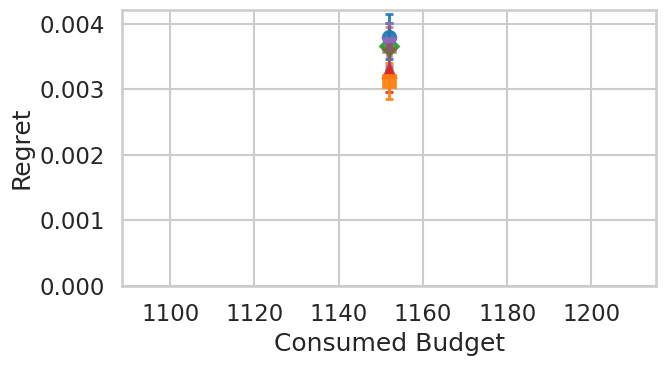

In [11]:
if not df_synthetic.empty:
    sh_synthetic = prepare_data(df_synthetic, "successive_halving")
    if sh_synthetic is not None:
        sh_synthetic = sh_synthetic[(sh_synthetic["sigma0"] == 0.0001) | (sh_synthetic["prior_kind"] == BASELINE_LABEL)]
        fig = pareto_plot(sh_synthetic)
        os.makedirs("plots/synthetic/successive_halving", exist_ok=True)
        fig.savefig("plots/synthetic/successive_halving/pareto.pdf", bbox_inches="tight")
        fig.savefig("plots/synthetic/successive_halving/pareto.png", bbox_inches="tight", dpi=300)
        plt.show()

## LCBench Ablation

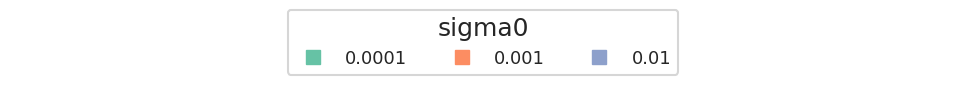

In [12]:
if not df_lcbench_unnorm.empty:
    _sigma_data = df_lcbench_unnorm[
        (df_lcbench_unnorm["optimizer"] == "successive_halving") & (df_lcbench_unnorm["use_early_stopping"] == 1)
    ]
    _sigma0_vals = sorted(_sigma_data["sigma0"].astype(str).unique())
    _set2 = sns.color_palette("Set2", n_colors=len(_sigma0_vals))
    _sigma_handles = [
        plt.Line2D([0], [0], marker="s", color="w",
                   markerfacecolor=c, markeredgecolor=c,
                   markersize=LEGEND_MARKER_SIZE, label=v)
        for v, c in zip(_sigma0_vals, _set2)
    ]
    _fig_ls, _ax_ls = plt.subplots(figsize=FIG_SIZE_LEGEND)
    _ax_ls.axis("off")
    _ax_ls.legend(
        handles=_sigma_handles,
        labels=[h.get_label() for h in _sigma_handles],
        loc="center",
        ncol=len(_sigma_handles),
        title="sigma0",
        frameon=True,
        fontsize=LABEL_SIZE,
    )
    plt.tight_layout()
    os.makedirs("plots/successive_halving", exist_ok=True)
    _fig_ls.savefig("plots/successive_halving/legend_sigma.pdf", bbox_inches="tight")
    _fig_ls.savefig("plots/successive_halving/legend_sigma.png", bbox_inches="tight", dpi=300)
    plt.show()

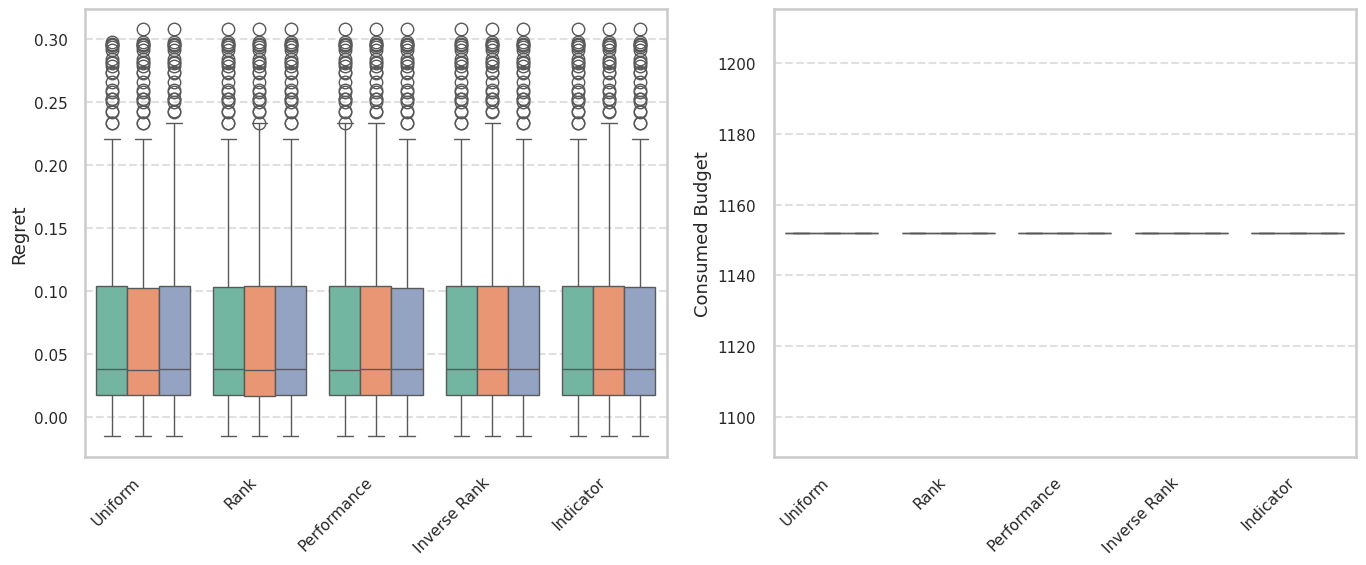

In [13]:
if not df_lcbench_unnorm.empty:
    fig = sigma_ablation_plot(df_lcbench_unnorm, "successive_halving")
    if fig is not None:
        os.makedirs("plots/successive_halving", exist_ok=True)
        fig.savefig("plots/successive_halving/sigma_ablation.pdf", bbox_inches="tight")
        fig.savefig("plots/successive_halving/sigma_ablation.png", bbox_inches="tight", dpi=300)
        plt.show()

## LCBench

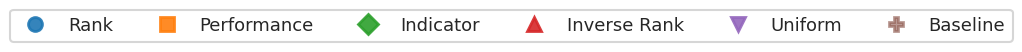

In [14]:
_prior_order = ["Rank", "Performance", "Indicator", "Inverse Rank", "Uniform", BASELINE_LABEL]
_pareto_handles = [
    plt.Line2D(
        [0], [0],
        marker=PRIOR_MARKER_MAP[p],
        color="w",
        markerfacecolor=PRIOR_COLOR_MAP[p],
        markeredgecolor=PRIOR_COLOR_MAP[p],
        markersize=LEGEND_MARKER_SIZE,
        markeredgewidth=MARKER_EDGE_WIDTH,
        alpha=ALPHA_BASELINE if p == BASELINE_LABEL else ALPHA_NORMAL,
        label=p,
    )
    for p in _prior_order
    if p in PRIOR_COLOR_MAP
]
_fig_lp, _ax_lp = plt.subplots(figsize=FIG_SIZE_LEGEND)
_ax_lp.axis("off")
_ax_lp.legend(
    handles=_pareto_handles,
    labels=[h.get_label() for h in _pareto_handles],
    loc="center",
    ncol=len(_pareto_handles),
    frameon=True,
    fontsize=LABEL_SIZE,
)
plt.tight_layout()
os.makedirs("plots/successive_halving", exist_ok=True)
_fig_lp.savefig("plots/successive_halving/legend_pareto.pdf", bbox_inches="tight")
_fig_lp.savefig("plots/successive_halving/legend_pareto.png", bbox_inches="tight", dpi=300)
plt.show()

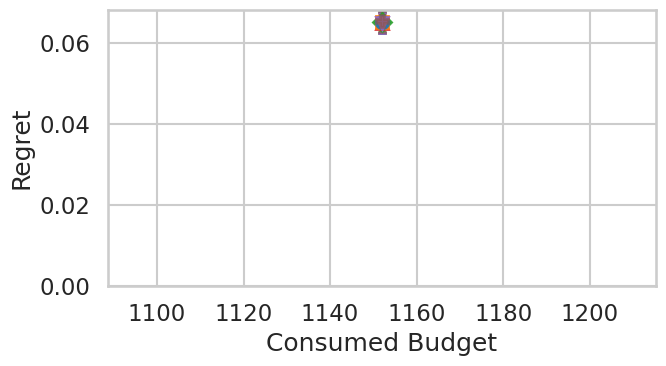

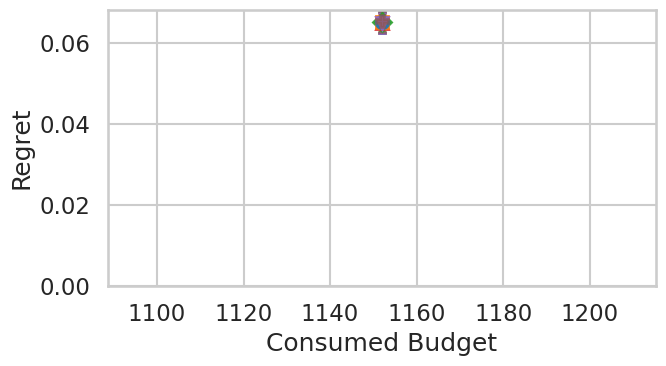

In [15]:
if not df_lcbench_unnorm.empty:
    sh_lcbench_unnorm = prepare_data(df_lcbench_unnorm, "successive_halving")
    if sh_lcbench_unnorm is not None:
        sh_lcbench_unnorm = sh_lcbench_unnorm[(sh_lcbench_unnorm["sigma0"] == 0.0001) | (sh_lcbench_unnorm["prior_kind"] == BASELINE_LABEL)]
        fig = pareto_plot(sh_lcbench_unnorm)
        os.makedirs("plots/successive_halving", exist_ok=True)
        fig.savefig("plots/successive_halving/pareto.pdf", bbox_inches="tight")
        fig.savefig("plots/successive_halving/pareto.png", bbox_inches="tight", dpi=300)
        plt.show()

sh_lcbench = prepare_data(df_lcbench, "successive_halving")
if sh_lcbench is not None:
    sh_lcbench = sh_lcbench[(sh_lcbench["sigma0"] == 0.0001) | (sh_lcbench["prior_kind"] == BASELINE_LABEL)]
    fig = pareto_plot(sh_lcbench)
    os.makedirs("plots/successive_halving", exist_ok=True)
    fig.savefig("plots/successive_halving/pareto_normalized.pdf", bbox_inches="tight")
    fig.savefig("plots/successive_halving/pareto_normalized.png", bbox_inches="tight", dpi=300)
    plt.show()

## Variance Over Time

2026-05-04 09:41:10,896  | py-experimenter - INFO     | Found 14 keyfields
2026-05-04 09:41:10,897  | py-experimenter - INFO     | Found 6 resultfields
2026-05-04 09:41:10,898  | py-experimenter - INFO     | Found 2 logtables
2026-05-04 09:41:10,898  | py-experimenter - INFO     | Found logtable test_priorband__sh_iterations
2026-05-04 09:41:10,898  | py-experimenter - INFO     | Found logtable test_priorband__brackets
2026-05-04 09:41:10,898  | py-experimenter - WARNING  | No custom section defined in config
2026-05-04 09:41:10,899  | py-experimenter - WARNING  | No codecarbon section defined in config
2026-05-04 09:41:10,904  | py-experimenter - INFO     | Initialized and connected to database
2026-05-04 09:41:10,938  | py-experimenter - INFO     | Found 14 keyfields
2026-05-04 09:41:10,939  | py-experimenter - INFO     | Found 6 resultfields
2026-05-04 09:41:10,940  | py-experimenter - INFO     | Found 2 logtables
2026-05-04 09:41:10,940  | py-experimenter - INFO     | Found logtabl

Could not load 'new_stopping_successive_halving_es' from DB: Execution failed on sql 'SELECT * FROM new_stopping_successive_halving_es': (1146, "Table 'priorbai_neurips.new_stopping_successive_halving_es' doesn't exist")
  Falling back to cached data for 'new_stopping_successive_halving_es'.
Could not load logtable 'new_stopping_successive_halving_es' from DB: Execution failed on sql 'SELECT * FROM new_stopping_successive_halving_es__sh_iterations': (1146, "Table 'priorbai_neurips.new_stopping_successive_halving_es__sh_iterations' doesn't exist")
  Falling back to cached logtable for 'new_stopping_successive_halving_es'.


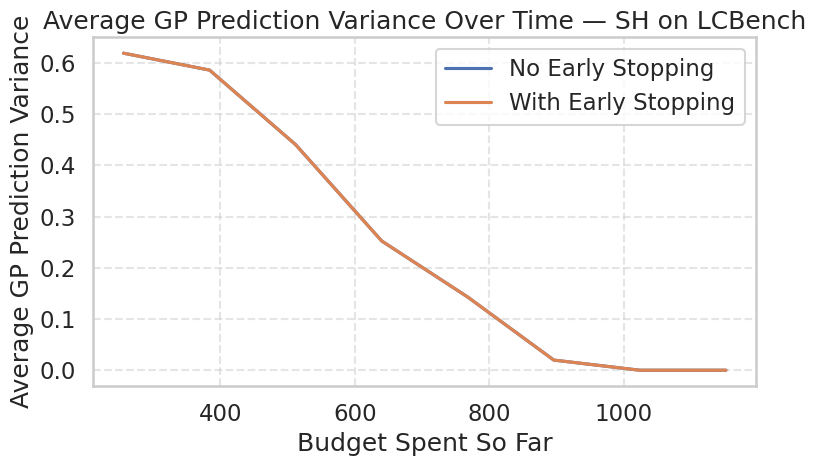

In [16]:
def get_logtable(table_name: str, update_data: bool) -> pd.DataFrame | None:
    cache_path = f"plain_data/{table_name}/logtable.csv"
    if update_data:
        try:
            experimenter = PyExperimenter(
                experiment_configuration_file_path="conf/experiment_config.yml",
                database_credential_file_path="conf/database_credentials.yml",
                table_name=table_name,
            )
            log_df = experimenter.get_logtable("sh_iterations")
            os.makedirs(os.path.dirname(cache_path), exist_ok=True)
            log_df.to_csv(cache_path, index=False)
            return log_df
        except Exception as e:
            print(f"Could not load logtable '{table_name}' from DB: {e}")
            if os.path.exists(cache_path):
                print(f"  Falling back to cached logtable for '{table_name}'.")
                return pd.read_csv(cache_path)
            return None
    else:
        if not os.path.exists(cache_path):
            print(f"No logtable cache found for '{table_name}', skipping.")
            return None
        return pd.read_csv(cache_path)


import ast

sh_log_dfs = []
for table_name in TABLE_NAMES_SH_UNNORMALIZED:
    main_df = get_data(table_name, update_data)
    log_df = get_logtable(table_name, update_data)
    if main_df is None or log_df is None:
        continue
    lcbench_ids = main_df[main_df["benchmark"] == "lcbench"]["ID"]
    log_df = log_df[log_df["experiment_id"].isin(lcbench_ids)].copy()
    log_df["use_early_stopping"] = main_df.set_index("ID").loc[
        log_df["experiment_id"].values, "use_early_stopping"
    ].values
    sh_log_dfs.append(log_df)

sh_log = pd.concat(sh_log_dfs, ignore_index=True)
sh_log["variance"] = sh_log["arm_prediction_variances"].map(
    lambda s: float(np.mean(ast.literal_eval(s)))
)
sh_log["variant"] = sh_log["use_early_stopping"].map({0: "No Early Stopping", 1: "With Early Stopping"})

avg_variance = (
    sh_log
    .groupby(["variant", "budget_spent_so_far"])["variance"]
    .agg(mean="mean", se=lambda x: x.std() / len(x) ** 0.5)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
for variant, grp in avg_variance.groupby("variant"):
    grp = grp.sort_values("budget_spent_so_far")
    ax.plot(grp["budget_spent_so_far"], grp["mean"], label=variant)
    ax.fill_between(
        grp["budget_spent_so_far"],
        grp["mean"] - grp["se"],
        grp["mean"] + grp["se"],
        alpha=0.2,
    )

ax.set_xlabel("Budget Spent So Far")
ax.set_ylabel("Average GP Prediction Variance")
ax.set_title("Average GP Prediction Variance Over Time — SH on LCBench")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
os.makedirs("plots/variance", exist_ok=True)
plt.savefig("plots/variance/variance_over_time_lcbench.pdf", bbox_inches="tight")
plt.savefig("plots/variance/variance_over_time_lcbench.png", bbox_inches="tight")
plt.show()


## Hyperband

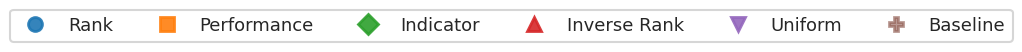

In [17]:
_prior_order = ["Rank", "Performance", "Indicator", "Inverse Rank", "Uniform", BASELINE_LABEL]
_pareto_handles = [
    plt.Line2D(
        [0], [0],
        marker=PRIOR_MARKER_MAP[p],
        color="w",
        markerfacecolor=PRIOR_COLOR_MAP[p],
        markeredgecolor=PRIOR_COLOR_MAP[p],
        markersize=LEGEND_MARKER_SIZE,
        markeredgewidth=MARKER_EDGE_WIDTH,
        alpha=ALPHA_BASELINE if p == BASELINE_LABEL else ALPHA_NORMAL,
        label=p,
    )
    for p in _prior_order
    if p in PRIOR_COLOR_MAP
]
_fig_lp, _ax_lp = plt.subplots(figsize=FIG_SIZE_LEGEND)
_ax_lp.axis("off")
_ax_lp.legend(
    handles=_pareto_handles,
    labels=[h.get_label() for h in _pareto_handles],
    loc="center",
    ncol=len(_pareto_handles),
    frameon=True,
    fontsize=LABEL_SIZE,
)
plt.tight_layout()
os.makedirs("plots/hyperband", exist_ok=True)
_fig_lp.savefig("plots/hyperband/legend_pareto.pdf", bbox_inches="tight")
_fig_lp.savefig("plots/hyperband/legend_pareto.png", bbox_inches="tight", dpi=300)
plt.show()

In [18]:
hb_lcbench = prepare_data(df_lcbench, "hyperband")
hb_lcbench

,ID,run_id,optimizer,num_arms,benchmark,kernel,use_predicted_y,use_early_stopping,seed,dataset_id,...,name,machine,T_max,consumed_budget,remaining_arms,num_epsilon_optimal_arms,regret,epsilon_optimal,end_date,error
0,203,__AUTO__,hyperband,256,lcbench,linear,0,1,2,10,...,PyExperimenter,login2,52.0,1091.0,1.0,2.0,0.045066,0.0,2026-05-02 16:56:41,NaN
1,604,__AUTO__,hyperband,256,lcbench,linear,0,1,3,30,...,PyExperimenter,login2,52.0,1091.0,1.0,4.0,0.051198,0.0,2026-05-02 16:56:40,NaN
2,1525,__AUTO__,hyperband,256,lcbench,linear,0,1,4,8,...,PyExperimenter,login2,52.0,1091.0,1.0,4.0,0.017039,0.0,2026-05-02 16:56:42,NaN
3,1782,__AUTO__,hyperband,256,lcbench,linear,0,1,1,21,...,PyExperimenter,login2,52.0,1091.0,1.0,4.0,0.055113,0.0,2026-05-02 16:56:41,NaN
4,3241,__AUTO__,hyperband,256,lcbench,linear,0,1,0,26,...,PyExperimenter,login2,52.0,1091.0,1.0,2.0,0.037637,0.0,2026-05-02 16:56:40,NaN


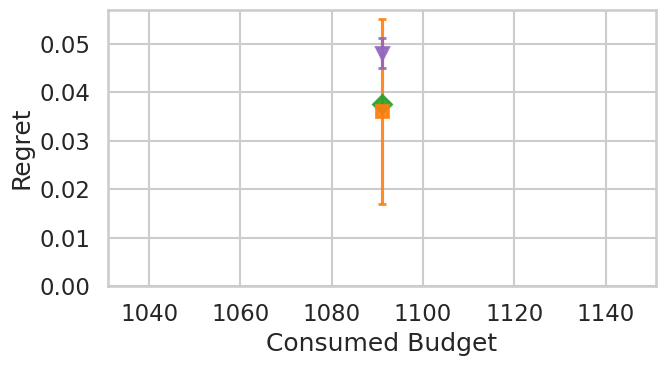

In [19]:
if hb_lcbench is not None:
    os.makedirs("plots/hyperband", exist_ok=True)
    fig = pareto_plot(hb_lcbench)
    fig.savefig("plots/hyperband/pareto.pdf", bbox_inches="tight")
    fig.savefig("plots/hyperband/pareto.png", bbox_inches="tight", dpi=300)
    plt.show()

## PriorBand

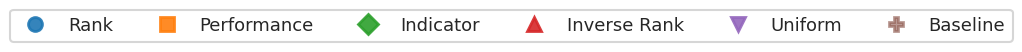

In [20]:
_prior_order = ["Rank", "Performance", "Indicator", "Inverse Rank", "Uniform", BASELINE_LABEL]
_pareto_handles = [
    plt.Line2D(
        [0], [0],
        marker=PRIOR_MARKER_MAP[p],
        color="w",
        markerfacecolor=PRIOR_COLOR_MAP[p],
        markeredgecolor=PRIOR_COLOR_MAP[p],
        markersize=LEGEND_MARKER_SIZE,
        markeredgewidth=MARKER_EDGE_WIDTH,
        alpha=ALPHA_BASELINE if p == BASELINE_LABEL else ALPHA_NORMAL,
        label=p,
    )
    for p in _prior_order
    if p in PRIOR_COLOR_MAP
]
_fig_lp, _ax_lp = plt.subplots(figsize=FIG_SIZE_LEGEND)
_ax_lp.axis("off")
_ax_lp.legend(
    handles=_pareto_handles,
    labels=[h.get_label() for h in _pareto_handles],
    loc="center",
    ncol=len(_pareto_handles),
    frameon=True,
    fontsize=LABEL_SIZE,
)
plt.tight_layout()
os.makedirs("plots/priorband", exist_ok=True)
_fig_lp.savefig("plots/priorband/legend_pareto.pdf", bbox_inches="tight")
_fig_lp.savefig("plots/priorband/legend_pareto.png", bbox_inches="tight", dpi=300)
plt.show()

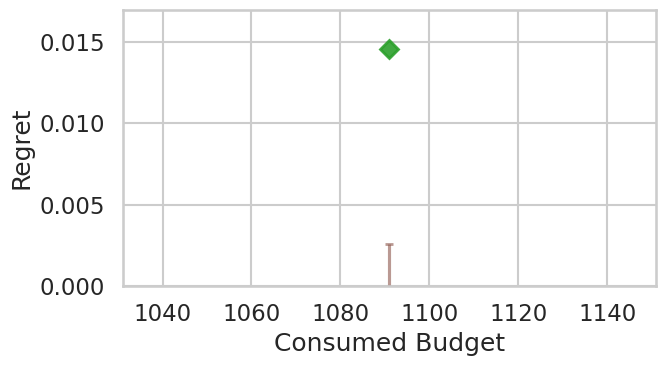

In [21]:
pb_lcbench = prepare_data(df_lcbench, "priorband")
if pb_lcbench is not None:
    os.makedirs("plots/priorband", exist_ok=True)
    fig = pareto_plot(pb_lcbench)
    fig.savefig("plots/priorband/pareto.pdf", bbox_inches="tight")
    fig.savefig("plots/priorband/pareto.png", bbox_inches="tight", dpi=300)
    plt.show()

### Joined Pareto Front

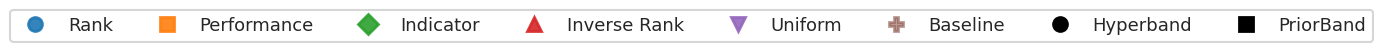

In [22]:
_prior_order = ["Rank", "Performance", "Indicator", "Inverse Rank", "Uniform", BASELINE_LABEL]
_color_handles = [
    plt.Line2D(
        [0], [0],
        marker=PRIOR_MARKER_MAP.get(p, "o"),
        color="w",
        markerfacecolor=PRIOR_COLOR_MAP.get(p, "gray"),
        markeredgecolor=PRIOR_COLOR_MAP.get(p, "gray"),
        markersize=LEGEND_MARKER_SIZE,
        markeredgewidth=MARKER_EDGE_WIDTH,
        alpha=ALPHA_BASELINE if p == BASELINE_LABEL else ALPHA_NORMAL,
        label=p,
    )
    for p in _prior_order
    if p in PRIOR_COLOR_MAP
]
_marker_handles = [
    plt.Line2D(
        [0], [0],
        marker=m,
        color="w",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=LEGEND_MARKER_SIZE,
        markeredgewidth=MARKER_EDGE_WIDTH,
        label=label,
    )
    for label, m in OPTIMIZER_MARKER.items()
]
_all_handles = _color_handles + _marker_handles
_fig_lj, _ax_lj = plt.subplots(figsize=FIG_SIZE_LEGEND)
_ax_lj.axis("off")
_ax_lj.legend(
    handles=_all_handles,
    labels=[h.get_label() for h in _all_handles],
    loc="center",
    ncol=len(_all_handles),
    frameon=True,
    fontsize=LABEL_SIZE,
)
plt.tight_layout()
os.makedirs("plots/priorband", exist_ok=True)
_fig_lj.savefig("plots/priorband/legend_joined.pdf", bbox_inches="tight")
_fig_lj.savefig("plots/priorband/legend_joined.png", bbox_inches="tight", dpi=300)
plt.show()

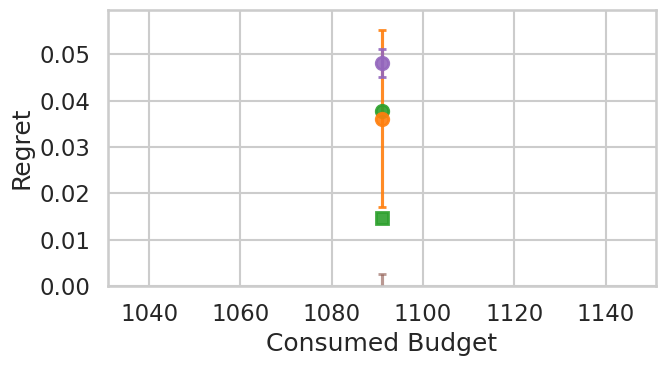

In [23]:
if hb_lcbench is not None and pb_lcbench is not None:
    os.makedirs("plots/priorband", exist_ok=True)
    fig = joined_pareto_plot(hb_lcbench, pb_lcbench)
    fig.savefig("plots/priorband/joined_pareto.pdf", bbox_inches="tight")
    fig.savefig("plots/priorband/joined_pareto.png", bbox_inches="tight", dpi=300)
    plt.show()